In [1]:
import xarray as xr
import glob
from dask_jobqueue import PBSCluster
from dask.distributed import Client
import numpy as np

In [2]:
sstds = xr.open_dataset('/glade/campaign/cgd/cas/observations/ERA5/mon/sst/era5.sst.194001-202512.nc')
sstds

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.Dataset> Size: 4GB
Dimensions:     (valid_time: 1032, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
    expver      (valid_time) <U4 17kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
Data variables:
    sst         (valid_time, latitude, longitude) float32 4GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-10T11:38 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
sst_clim = sstds['sst'].groupby('valid_time.month').mean()

In [4]:
sst_clim

<xarray.DataArray 'sst' (month: 12, latitude: 721, longitude: 1440)> Size: 50MB
array([[[271.46   , 271.46   , 271.46   , ..., 271.46   , 271.46   ,
         271.46   ],
        [271.46   , 271.45996, 271.46   , ..., 271.46   , 271.46   ,
         271.46   ],
        [271.46   , 271.46   , 271.46   , ..., 271.45996, 271.46   ,
         271.46   ],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[271.46   , 271.46   , 271.46   , ..., 271.46   , 271.46   ,
         271.46   ],
        [271.46   , 271.45996, 271.46   , ..., 271.46   , 271.46   ,
         271.46   ],
        [271.46   , 271.46   , 271.46   , ..., 271.46   , 271.46   ,
         271.46   ],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[271.46   , 271.46   , 271.46   , ..., 271.46   , 271.46   ,
         271.46   ],
        [271.46   , 271.46   , 271.46   , ..., 271.46   , 271.46   ,
         271.46   ],
        [271.46   , 271.46   , 271.46   , ..., 271.46   , 271.46   ,
         271.46   ],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], shape=(12, 721, 1440), dtype=float32)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           sst
    GRIB_units:                               K
    long_name:                                Sea surface temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [10]:
sst_anom = sstds['sst'].groupby('valid_time.month') - sst_clim
sst_anom

<xarray.DataArray 'sst' (valid_time: 1032, latitude: 721, longitude: 1440)> Size: 4GB
array([[[-2.7465820e-04, -2.7465820e-04, -2.7465820e-04, ...,
         -2.7465820e-04, -2.7465820e-04, -2.7465820e-04],
        [-2.7465820e-04, -2.4414062e-04, -2.7465820e-04, ...,
         -2.7465820e-04, -2.7465820e-04, -2.7465820e-04],
        [-2.7465820e-04, -2.7465820e-04, -2.7465820e-04, ...,
         -2.4414062e-04, -2.7465820e-04, -2.7465820e-04],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[-3.0517578e-05, -3.0517578e-05, -3.0517578e-05, ...,
         -3.0517578e-05, -3.0517578e-05, -3.0517578e-05],
        [-3.0517578e-05,  0.0000000e+00, -3.0517578e-05, ...,
         -3.0517578e-05, -3.0517578e-05, -3.0517578e-05],
        [-3.0517578e-05, -3.0517578e-05, -3.0517578e-05, ...,
         -3.0517578e-05, -3.0517578e-05, -3.0517578e-05],
...
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[-2.7465820e-04, -2.7465820e-04, -2.7465820e-04, ...,
         -2.7465820e-04, -2.7465820e-04, -2.7465820e-04],
        [-2.7465820e-04, -2.7465820e-04, -2.7465820e-04, ...,
         -2.7465820e-04, -2.7465820e-04, -2.7465820e-04],
        [-2.7465820e-04, -2.7465820e-04, -2.7465820e-04, ...,
         -2.7465820e-04, -2.7465820e-04, -2.7465820e-04],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]],
      shape=(1032, 721, 1440), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
    number      (valid_time) int64 8kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    expver      (valid_time) <U4 17kB '0001' '0001' '0001' ... '0001' '0005'
    month       (valid_time) int64 8kB 1 2 3 4 5 6 7 8 9 ... 5 6 7 8 9 10 11 12
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes: (12/31)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           sst
    GRIB_units:                               K
    long_name:                                Sea surface temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

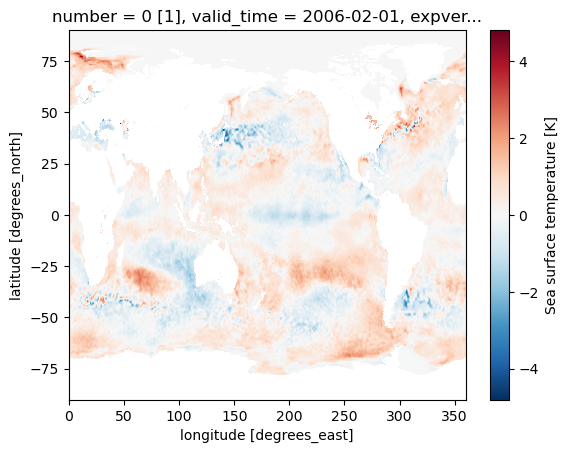

In [12]:
sst_anom.isel(valid_time=793).plot()

In [13]:
sst_anom.to_netcdf('/glade/work/acruz/Caribbean_Heat_data/ERA5/sst_anom_monthly.nc')